# Two-reference initialization-drift analysis

Consume only the prepared monthly products from `0_run_drift_references.ipynb` and compute the complete matrix: May and November initialization, TREFHT and SST, Reanalysis and JRA55_FOSIRL. The calculation retains initialization year `Y`, averages only ensemble member `M`, and produces regional diagnostics, compact spatial maps, paired FOSIRL-minus-Reanalysis comparisons, skill, drift–skill relationships, and historical-spread-normalized attractor departures.

In [32]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import xarray as xr
import esp_lab

REPO_ROOT = Path(esp_lab.__file__).resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from esp_lab.diagnostics.two_reference_drift import (
    area_weighted_mean, bootstrap_paired_mean_ci, compare_drift_skill_relationship,
    compare_initializations, compute_diagnostics, compute_early_drift_late_error,
    compute_regime_fraction, compute_spatial_drift_summary, regional_subset,
    run_pipeline as run_two_reference_pipeline,
)
from workflows.diagnostics import two_reference_drift as drift_workflow
drift_workflow = importlib.reload(drift_workflow)
apply_unit_transform = drift_workflow.apply_unit_transform
atomic_to_netcdf = drift_workflow.atomic_to_netcdf
discover_monthly_hindcast = drift_workflow.discover_monthly_hindcast
load_drift_references = drift_workflow.load_drift_references
select_initialization_years = drift_workflow.select_initialization_years

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Analysis matrix and conventions

In [33]:
SOURCES = ('Reanalysis', 'JRA55_FOSIRL')
ANALYSIS_YEARS = (1980, 2017)
BASELINE_LEAD = 1
DISTANCE_TOLERANCE = 1.0e-6
N_BOOTSTRAP = 1000
BOOTSTRAP_SEED = 42
LEAD_WINDOWS = drift_workflow.DEFAULT_LEAD_WINDOWS
EARLY_LEADS = LEAD_WINDOWS['early_adjustment']
LATE_LEADS = LEAD_WINDOWS['extended_seasonal']
DRIFT_SKILL_ERROR_WINDOWS = tuple(
    tuple(range(start, start + 3)) for start in range(7, 25, 3)
)

ANALYSES = [
    {'variable': variable, 'component': component, 'init_month': init_month}
    for variable, component in (('TREFHT', 'atm'), ('SST', 'ocn'))
    for init_month in (5, 11)
]
REGIONS = {
    'TREFHT': {'name': 'Nino3.4', 'lon_bounds': (190, 240), 'lat_bounds': (-5, 5)},
    'SST': {'name': 'Nino3.4', 'lon_bounds': (190, 240), 'lat_bounds': (-5, 5)},
}
OUTPUT_ROOT = Path('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference')
FIGURE_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
REUSE_EXISTING_OUTPUTS_FOR_FIGURES = True
SHOW_FIGURES_INLINE = True
FIGURE_PREFIX = 'fig_leadtime_drift_two_reference'
MONTH_NAMES = {5: 'May', 11: 'November'}
INIT_MONTHS = tuple(MONTH_NAMES)

# Central figure controls. FIGURE_SCALE multiplies every base width and height.
FIGURE_SCALE = 1.0
FIGURE_DPI = 160
FONT_SIZE = 10
TITLE_FONT_SIZE = 12
LEGEND_FONT_SIZE = 8
FIGURE_BASE_SIZES = {
    'regional_drift': (18, 8),
    'skill': (18, 8),
    'regime_fraction': (14, 9),
    'spatial_maps': (18, 14),
    'drift_skill': (12, 18),
}


def figure_size(name):
    return tuple(FIGURE_SCALE * value for value in FIGURE_BASE_SIZES[name])


def lead_month_range(leads):
    return f'Months {int(leads[0])}–{int(leads[-1])}'


plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'figure.titlesize': TITLE_FONT_SIZE,
    'legend.fontsize': LEGEND_FONT_SIZE,
})

## 2. Compute start-specific regional and spatial diagnostics

Spatial fields remain start-specific through the drift calculation. Only afterward are they summarized across `Y` and explicit lead windows. Regime maps contain category frequencies, never averages of integer category codes. `z_att = e_att / sigma_att`; non-positive historical spread is masked.

In [34]:
def _analysis_output_paths(variable, init_month):
    tag = f'{variable}_{init_month:02d}'
    paths = {}
    for source in SOURCES:
        paths[(source, 'regional')] = OUTPUT_ROOT / f'{source}_{tag}_regional.nc'
        paths[(source, 'spatial')] = OUTPUT_ROOT / f'{source}_{tag}_spatial_maps.nc'
    paths[('paired', 'regional')] = OUTPUT_ROOT / f'FOSIRL_minus_Reanalysis_{tag}_regional.nc'
    paths[('paired', 'spatial')] = OUTPUT_ROOT / f'FOSIRL_minus_Reanalysis_{tag}_spatial_maps.nc'
    return paths


def _load_dataset(path):
    with xr.open_dataset(path) as dataset:
        return dataset.load()


def _load_analysis_for_figures(variable, init_month):
    paths = _analysis_output_paths(variable, init_month)
    regional = {}
    skill = {}
    regime_fraction = {}
    spatial = {}
    drift_skill = {}
    regional_names = (
        'hindcast_mean', 'e_obs', 'e_att', 'delta_e_obs', 'delta_e_att',
        'delta_abs_e_obs', 'delta_abs_e_att', 'regime', 'z_att',
    )

    for source in SOURCES:
        saved = _load_dataset(paths[(source, 'regional')])
        regional[source] = saved[list(regional_names)]
        skill_names = [name for name in saved.data_vars if name.startswith('skill_')]
        skill[source] = saved[skill_names].rename(
            {name: name.removeprefix('skill_') for name in skill_names}
        )
        fraction_names = [name for name in saved.data_vars if name.startswith('fraction_regime_')]
        regime_fraction[source] = saved[fraction_names]
        spatial[source] = _load_dataset(paths[(source, 'spatial')])
        drift_skill[source] = compute_early_drift_late_error(
            regional[source].delta_abs_e_obs, regional[source].e_obs,
            early_leads=EARLY_LEADS, late_leads=LATE_LEADS,
        )

    paired = _load_dataset(paths[('paired', 'regional')])
    paired_fraction_names = [
        name for name in paired.data_vars if name.startswith('delta_fraction_regime_')
    ]
    paired_regime_fraction = paired[paired_fraction_names]
    paired_spatial = _load_dataset(paths[('paired', 'spatial')])
    paired_drift_skill = compare_drift_skill_relationship(
        drift_skill['JRA55_FOSIRL'], drift_skill['Reanalysis']
    )
    return {
        'regional': regional, 'skill': skill,
        'regime_fraction': regime_fraction, 'paired': paired,
        'paired_ci': {}, 'paired_regime_fraction': paired_regime_fraction,
        'drift_skill': drift_skill,
        'paired_drift_skill': paired_drift_skill, 'spatial': spatial,
        'paired_spatial': paired_spatial,
    }


required_analysis_paths = [
    path
    for analysis in ANALYSES
    for path in _analysis_output_paths(analysis['variable'], analysis['init_month']).values()
]
analysis_outputs_complete = all(
    path.is_file() and path.stat().st_size > 0 for path in required_analysis_paths
)
loaded_results_from_cache = REUSE_EXISTING_OUTPUTS_FOR_FIGURES and analysis_outputs_complete

results = {}
if loaded_results_from_cache:
    for analysis in ANALYSES:
        key = (analysis['variable'], analysis['init_month'])
        results[key] = _load_analysis_for_figures(*key)
    analyses_to_compute = []
    print(f'Loaded {len(results)} analyses from existing NetCDF outputs; skipped raw-data processing.')
else:
    analyses_to_compute = ANALYSES
    if REUSE_EXISTING_OUTPUTS_FOR_FIGURES:
        missing = [path for path in required_analysis_paths if not path.is_file() or path.stat().st_size == 0]
        print(f'Analysis cache incomplete ({len(missing)} files missing/empty); recomputing all analyses.')

for analysis in analyses_to_compute:
    variable = analysis['variable']
    component = analysis['component']
    init_month = analysis['init_month']
    key = (variable, init_month)
    region = REGIONS[variable]
    regional_hindcasts = {}
    regional_obs = {}
    regional_att = {}
    regional_spread = {}
    spatial = {}
    valid_times = {}

    for source in SOURCES:
        job = {
            'source': source, 'component': component, 'variable': variable,
            'init_month': init_month, 'regrid': True,
        }
        hindcast_path = discover_monthly_hindcast(job)
        with xr.open_dataset(hindcast_path, chunks={}) as hindcast_ds, load_drift_references(
            source, init_month, variable, component=component, hindcast=None,
            require_attractor_spread=True,
        ) as references:
            values = select_initialization_years(
                apply_unit_transform(hindcast_ds[variable], component, variable),
                ANALYSIS_YEARS,
            )
            references = references.sel(Y=values.Y)
            np.testing.assert_array_equal(references.L, values.L)
            np.testing.assert_array_equal(references.valid_time, hindcast_ds.time.sel(Y=values.Y))
            valid_times[source] = references.valid_time.load()

            regional_hindcasts[source] = area_weighted_mean(
                regional_subset(values, **{k: region[k] for k in ('lon_bounds', 'lat_bounds')})
            ).load()
            for destination, field in (
                (regional_obs, references.X_obs),
                (regional_att, references.X_att),
                (regional_spread, references.sigma_att),
            ):
                destination[source] = area_weighted_mean(
                    regional_subset(field, **{k: region[k] for k in ('lon_bounds', 'lat_bounds')})
                ).load()

            spatial_product = compute_diagnostics(
                values, references.X_obs, references.X_att,
                baseline_lead=BASELINE_LEAD, distance_tolerance=DISTANCE_TOLERANCE,
            )
            spatial_product['z_att'] = (
                spatial_product.e_att / references.sigma_att.where(references.sigma_att > 0)
            ).assign_attrs(
                units='1',
                diagnostic='departure from E3SM-LE attractor normalized by historical ensemble spread',
            )
            spatial[source] = compute_spatial_drift_summary(
                spatial_product, LEAD_WINDOWS
            ).compute()

    pipeline = run_two_reference_pipeline(
        regional_hindcasts, regional_obs, regional_att,
        attractor_spreads=regional_spread, baseline_lead=BASELINE_LEAD,
        distance_tolerance=DISTANCE_TOLERANCE,
    )
    regional_products = {
        source: xr.Dataset({
            name: pipeline[name][source]
            for name in (
                'hindcast_mean', 'e_obs', 'e_att', 'delta_e_obs', 'delta_e_att',
                'delta_abs_e_obs', 'delta_abs_e_att', 'regime', 'z_att',
            )
        }).assign_coords(valid_time=valid_times[source])
        for source in SOURCES
    }
    regime_fraction = {
        source: compute_regime_fraction(
            regional_products[source].regime, spatial_dims=(), sample_dims=('Y',)
        )
        for source in SOURCES
    }
    paired = pipeline['paired'].copy()
    paired['delta_z_att'] = compare_initializations(
        regional_products['JRA55_FOSIRL'].z_att, regional_products['Reanalysis'].z_att
    )
    paired_ci = {
        name: bootstrap_paired_mean_ci(
            field, n_bootstrap=N_BOOTSTRAP, seed=BOOTSTRAP_SEED
        )
        for name, field in paired.data_vars.items() if 'Y' in field.dims
    }
    paired_regime_fraction = compare_initializations(
        regime_fraction['JRA55_FOSIRL'], regime_fraction['Reanalysis']
    ).rename({name: f'delta_{name}' for name in regime_fraction['Reanalysis'].data_vars})
    drift_skill = {
        source: compute_early_drift_late_error(
            regional_products[source].delta_abs_e_obs, regional_products[source].e_obs,
            early_leads=EARLY_LEADS, late_leads=LATE_LEADS,
        )
        for source in SOURCES
    }
    paired_drift_skill = compare_drift_skill_relationship(
        drift_skill['JRA55_FOSIRL'], drift_skill['Reanalysis']
    )
    paired_spatial = compare_initializations(
        spatial['JRA55_FOSIRL'], spatial['Reanalysis']
    ).rename({name: f'delta_{name}' for name in spatial['Reanalysis'].data_vars})
    results[key] = {
        'regional': regional_products, 'skill': pipeline['skill'],
        'regime_fraction': regime_fraction, 'paired': paired,
        'paired_ci': paired_ci, 'paired_regime_fraction': paired_regime_fraction,
        'drift_skill': drift_skill,
        'paired_drift_skill': paired_drift_skill, 'spatial': spatial,
        'paired_spatial': paired_spatial,
    }
    print(f'Computed {variable} {MONTH_NAMES[init_month]}: Y={regional_products[SOURCES[0]].sizes["Y"]}, L={regional_products[SOURCES[0]].sizes["L"]}')

Loaded 4 analyses from existing NetCDF outputs; skipped raw-data processing.


## 3. Export compact, reusable products

In [35]:
output_paths = []
summary_rows = []
results_to_write = {} if loaded_results_from_cache else results
for (variable, init_month), result in results_to_write.items():
    tag = f'{variable}_{init_month:02d}'
    for source in SOURCES:
        regional = xr.merge(
            [result['regional'][source],
             result['skill'][source].rename({name: f'skill_{name}' for name in result['skill'][source].data_vars}),
             result['regime_fraction'][source]],
            compat='override', join='exact',
        )
        regional.attrs.update(
            source=source, variable=variable, initialization_month=init_month,
            region=REGIONS[variable]['name'], normalization='z_att=e_att/sigma_att',
        )
        path = OUTPUT_ROOT / f'{source}_{tag}_regional.nc'
        atomic_to_netcdf(regional, path)
        output_paths.append(path)
        spatial_path = OUTPUT_ROOT / f'{source}_{tag}_spatial_maps.nc'
        atomic_to_netcdf(result['spatial'][source], spatial_path)
        output_paths.append(spatial_path)
        summary_rows.append({
            'variable': variable, 'init_month': init_month, 'source': source,
            'drift_skill_correlation': float(result['drift_skill'][source].correlation),
        })

    paired_export = result['paired'].copy()
    paired_export = xr.merge(
        [paired_export, result['paired_regime_fraction']], compat='override', join='exact'
    )
    for name, interval in result['paired_ci'].items():
        for statistic in interval.data_vars:
            paired_export[f'{name}_{statistic}'] = interval[statistic]
    paired_export.attrs['comparison'] = 'JRA55_FOSIRL minus Reanalysis'
    paired_path = OUTPUT_ROOT / f'FOSIRL_minus_Reanalysis_{tag}_regional.nc'
    atomic_to_netcdf(paired_export, paired_path)
    output_paths.append(paired_path)
    spatial_path = OUTPUT_ROOT / f'FOSIRL_minus_Reanalysis_{tag}_spatial_maps.nc'
    atomic_to_netcdf(result['paired_spatial'], spatial_path)
    output_paths.append(spatial_path)
    summary_rows.append({
        'variable': variable, 'init_month': init_month, 'source': 'paired_difference',
        'drift_skill_correlation': float(result['paired_drift_skill'].correlation),
    })

summary_path = OUTPUT_ROOT / 'two_reference_drift_skill_summary.csv'
if loaded_results_from_cache:
    output_paths = required_analysis_paths.copy()
    if summary_path.is_file():
        output_paths.append(summary_path)
    print('Existing analysis outputs retained without rewriting them.')
else:
    pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
    output_paths.append(summary_path)
output_paths

Existing analysis outputs retained without rewriting them.


[PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/Reanalysis_TREFHT_05_regional.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/Reanalysis_TREFHT_05_spatial_maps.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/JRA55_FOSIRL_TREFHT_05_regional.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/JRA55_FOSIRL_TREFHT_05_spatial_maps.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/FOSIRL_minus_Reanalysis_TREFHT_05_regional.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/FOSIRL_minus_Reanalysis_TREFHT_05_spatial_maps.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/Reanalysis_TREFHT_11_regional.nc'),
 PosixPath('/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/

## 4. Regional curves, spatial maps, and drift–skill relationships

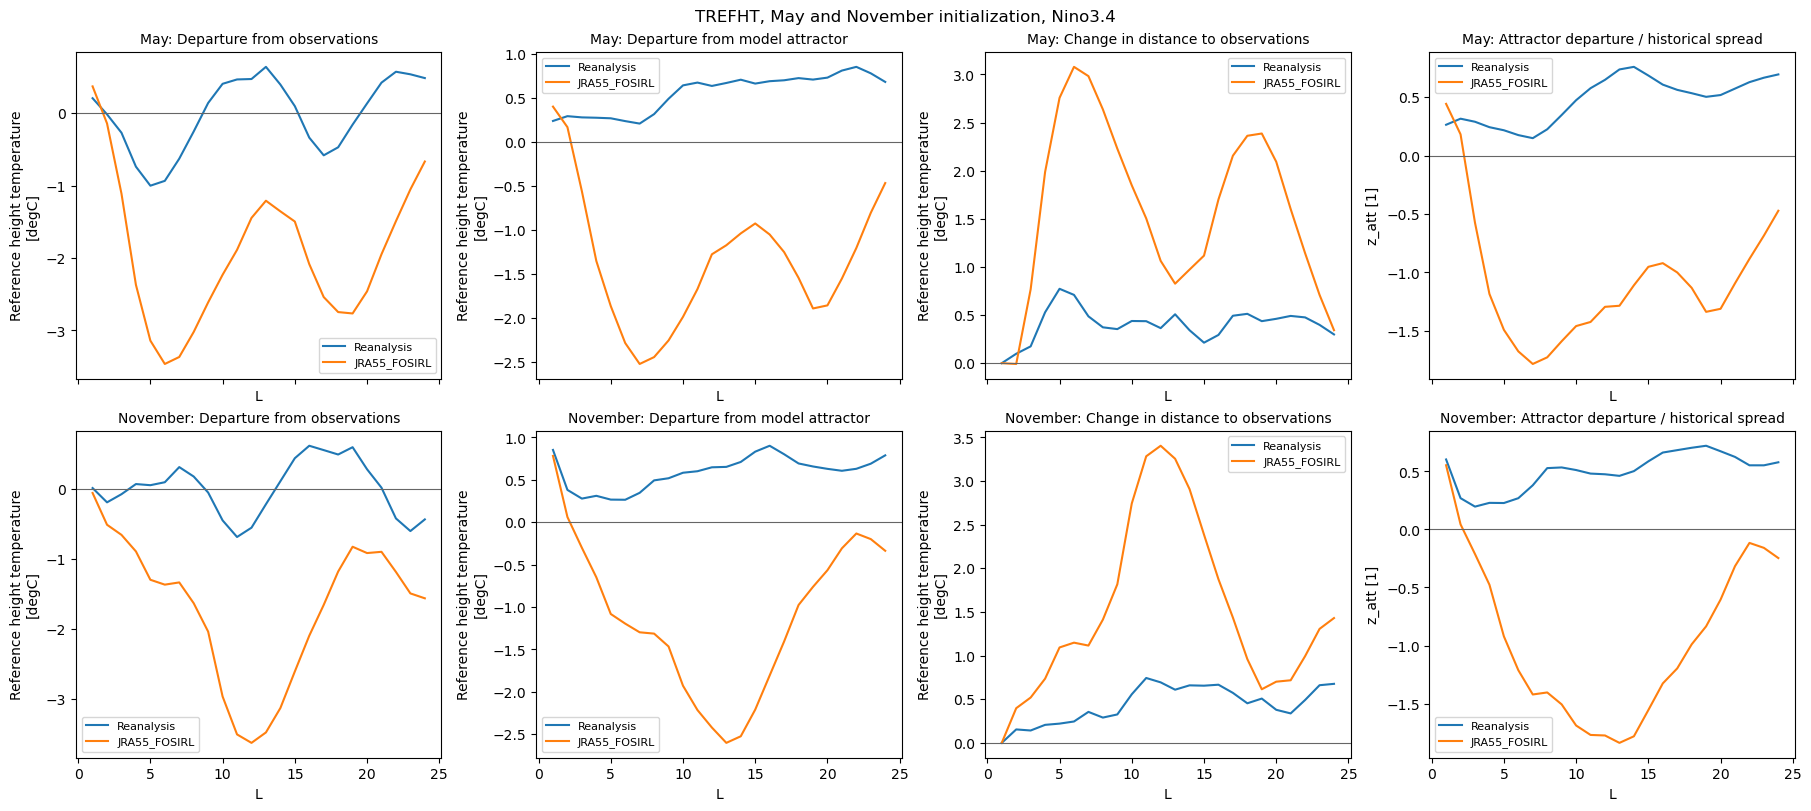

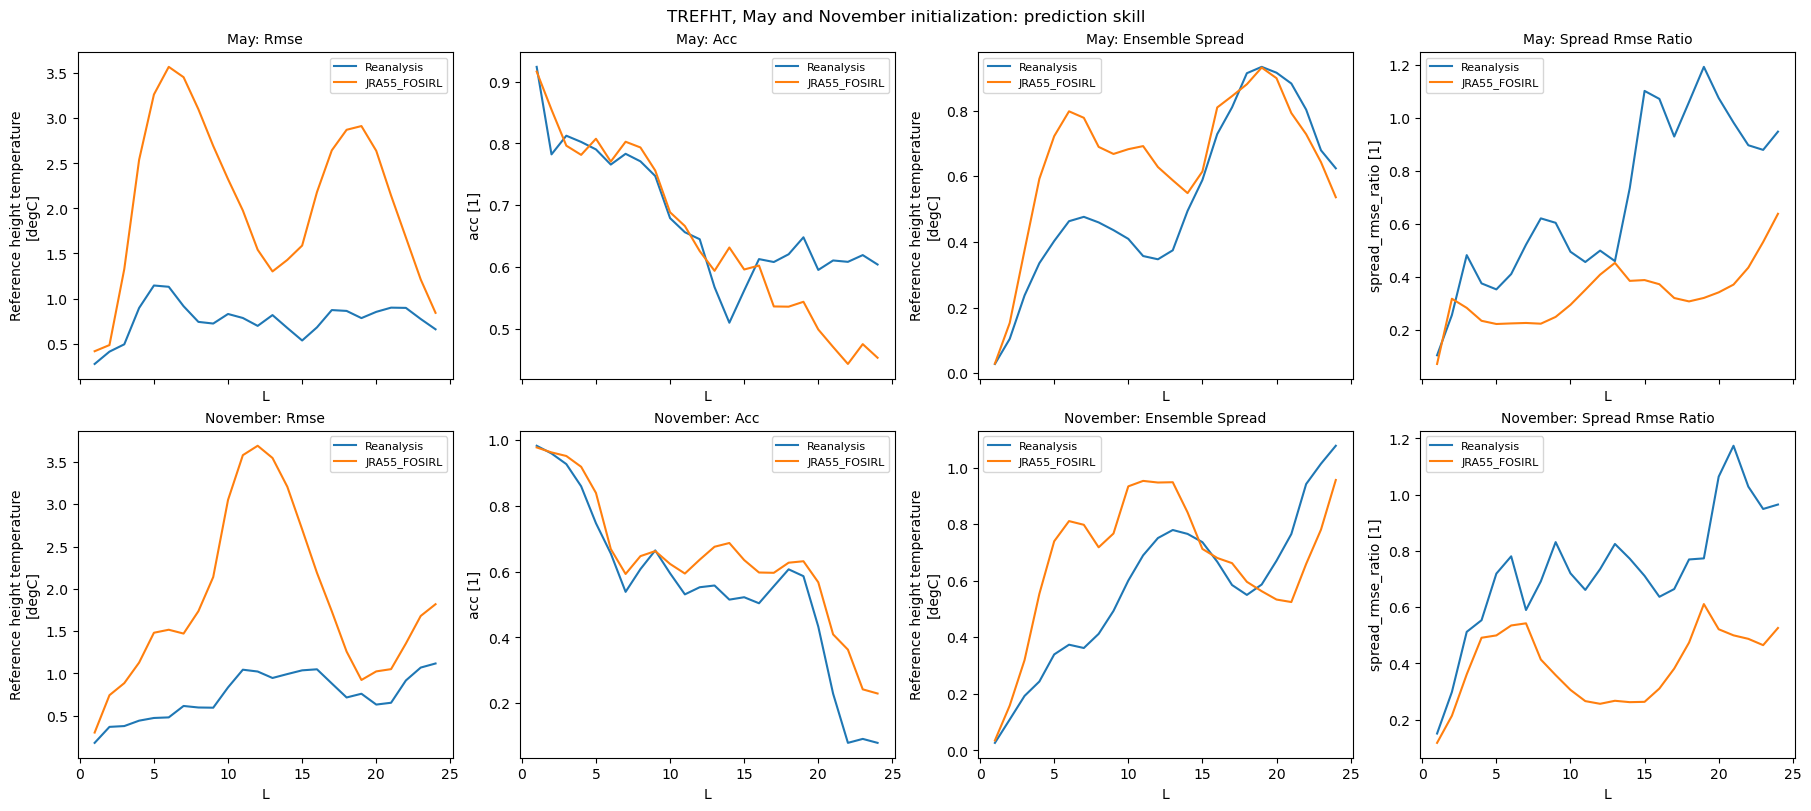

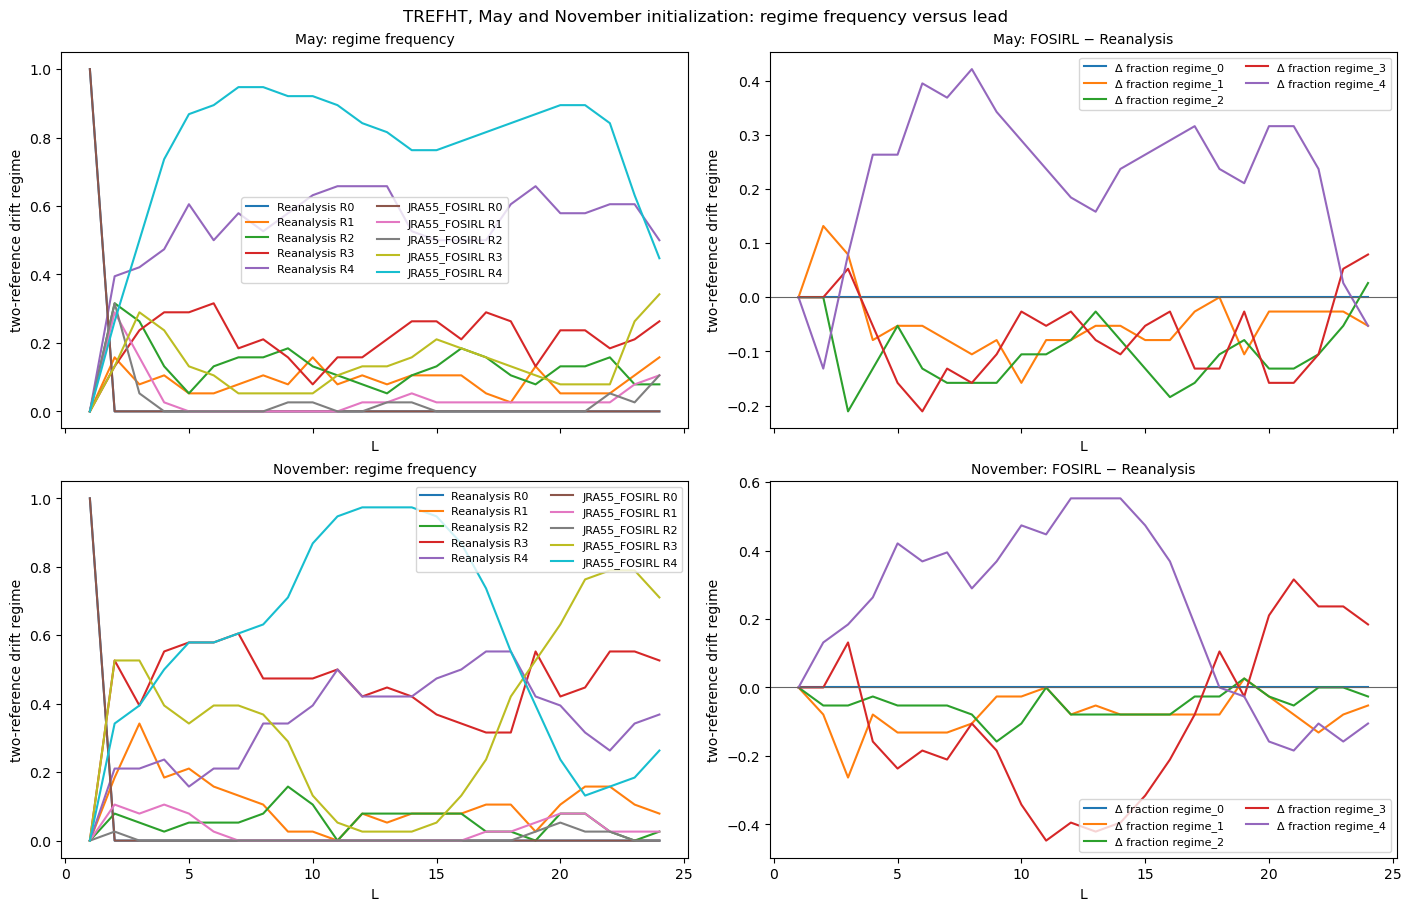

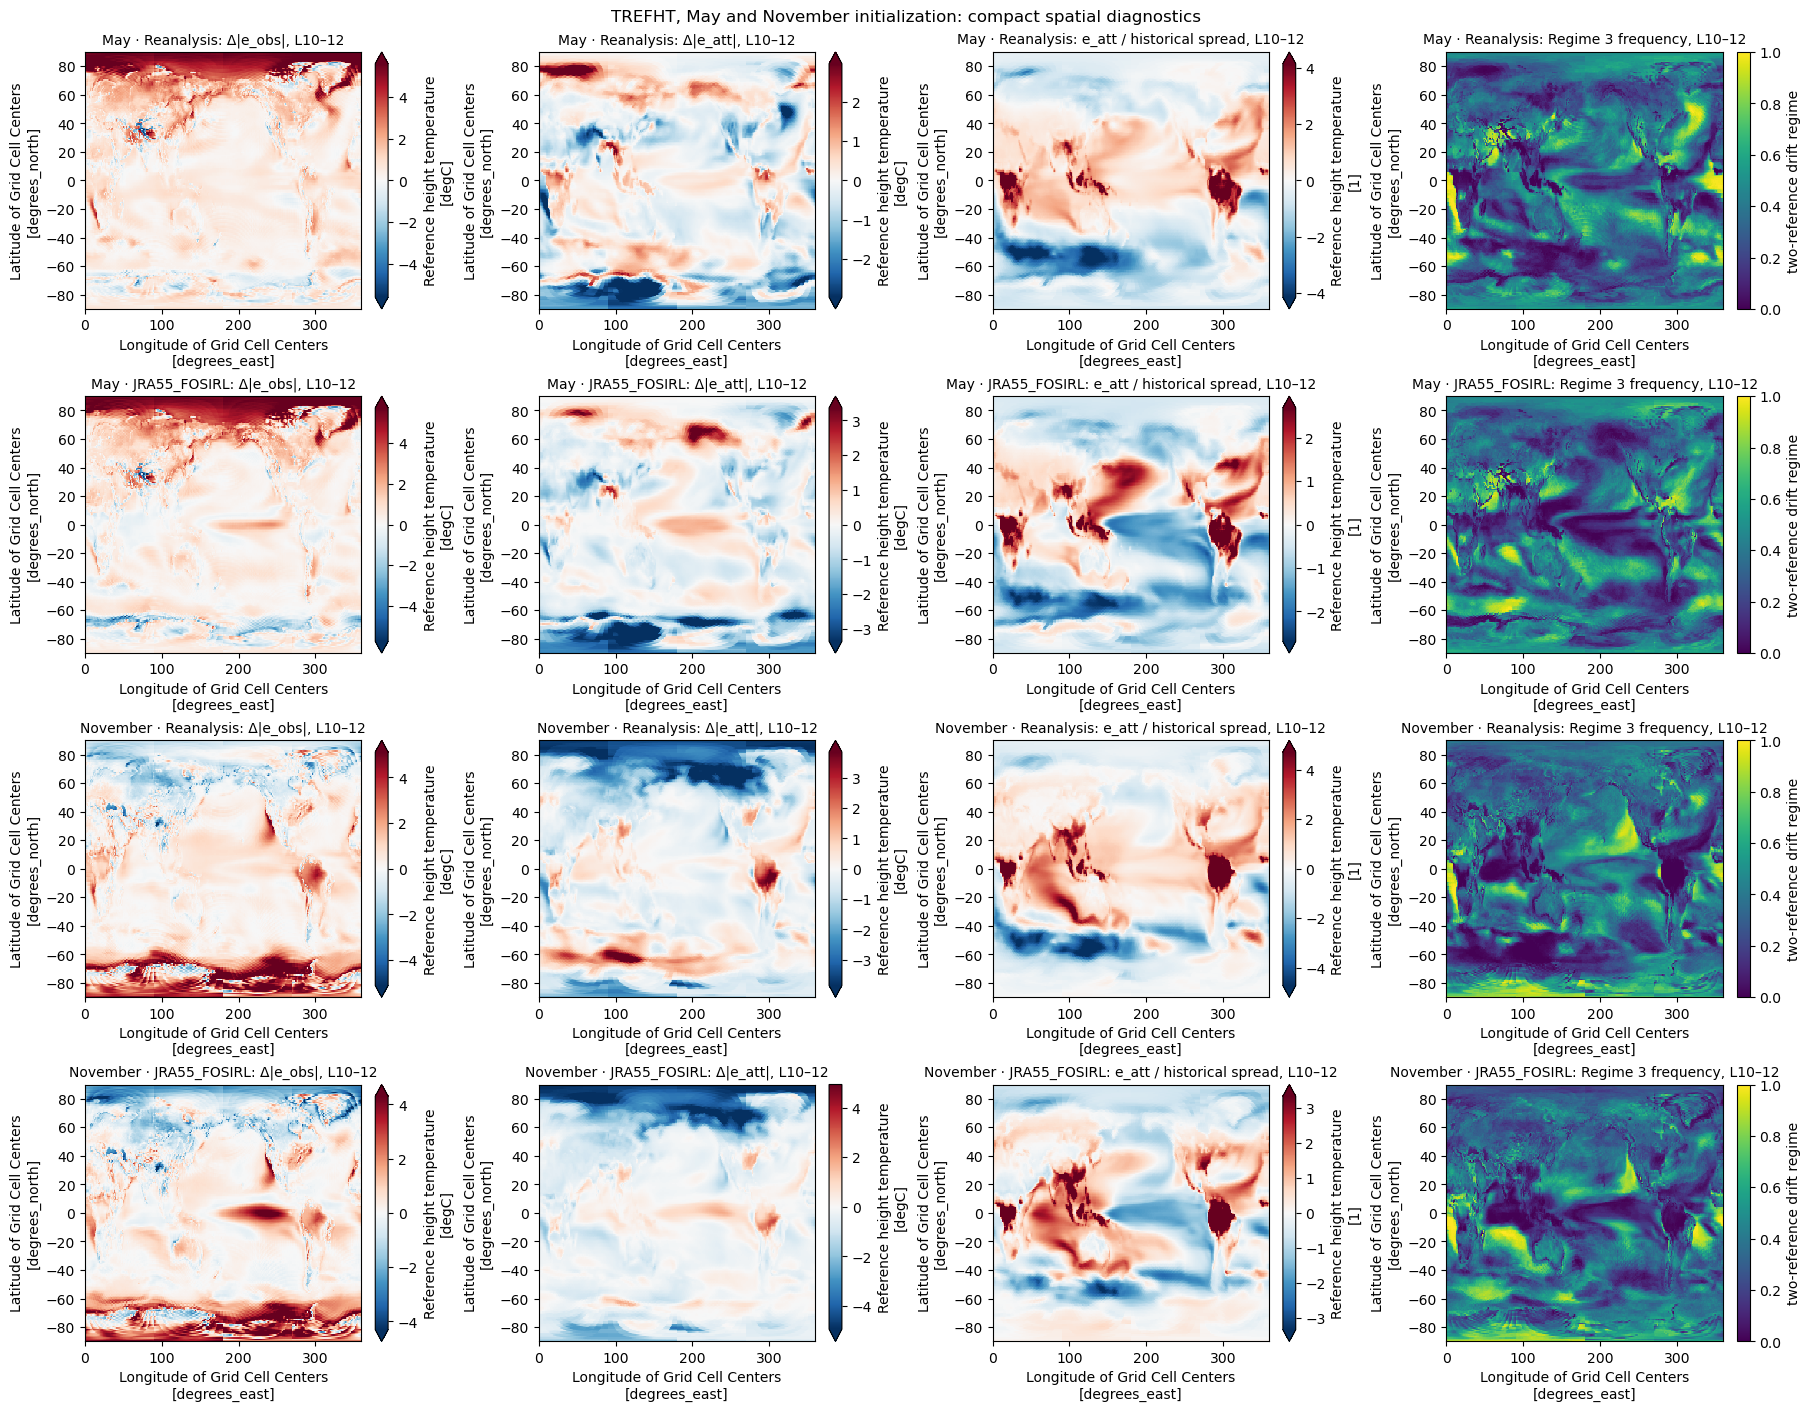

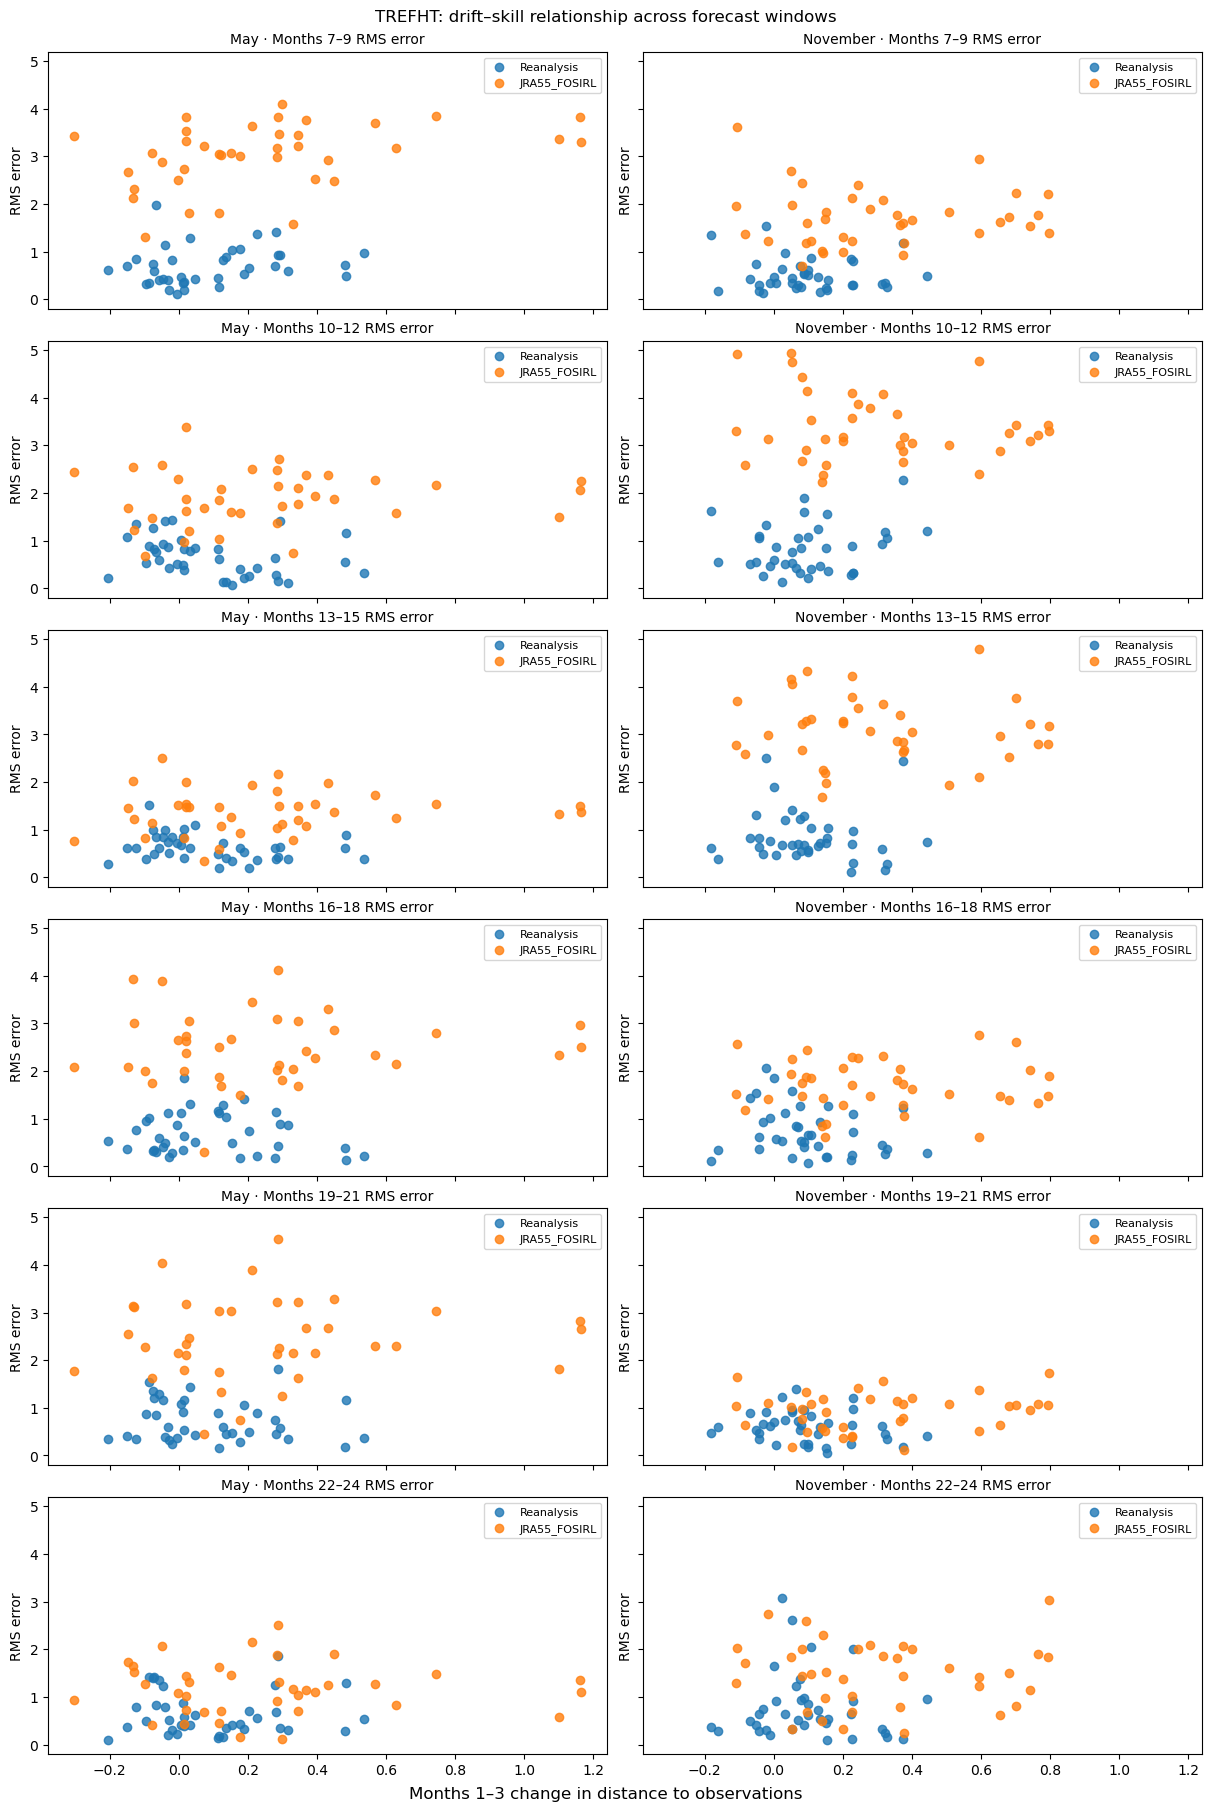

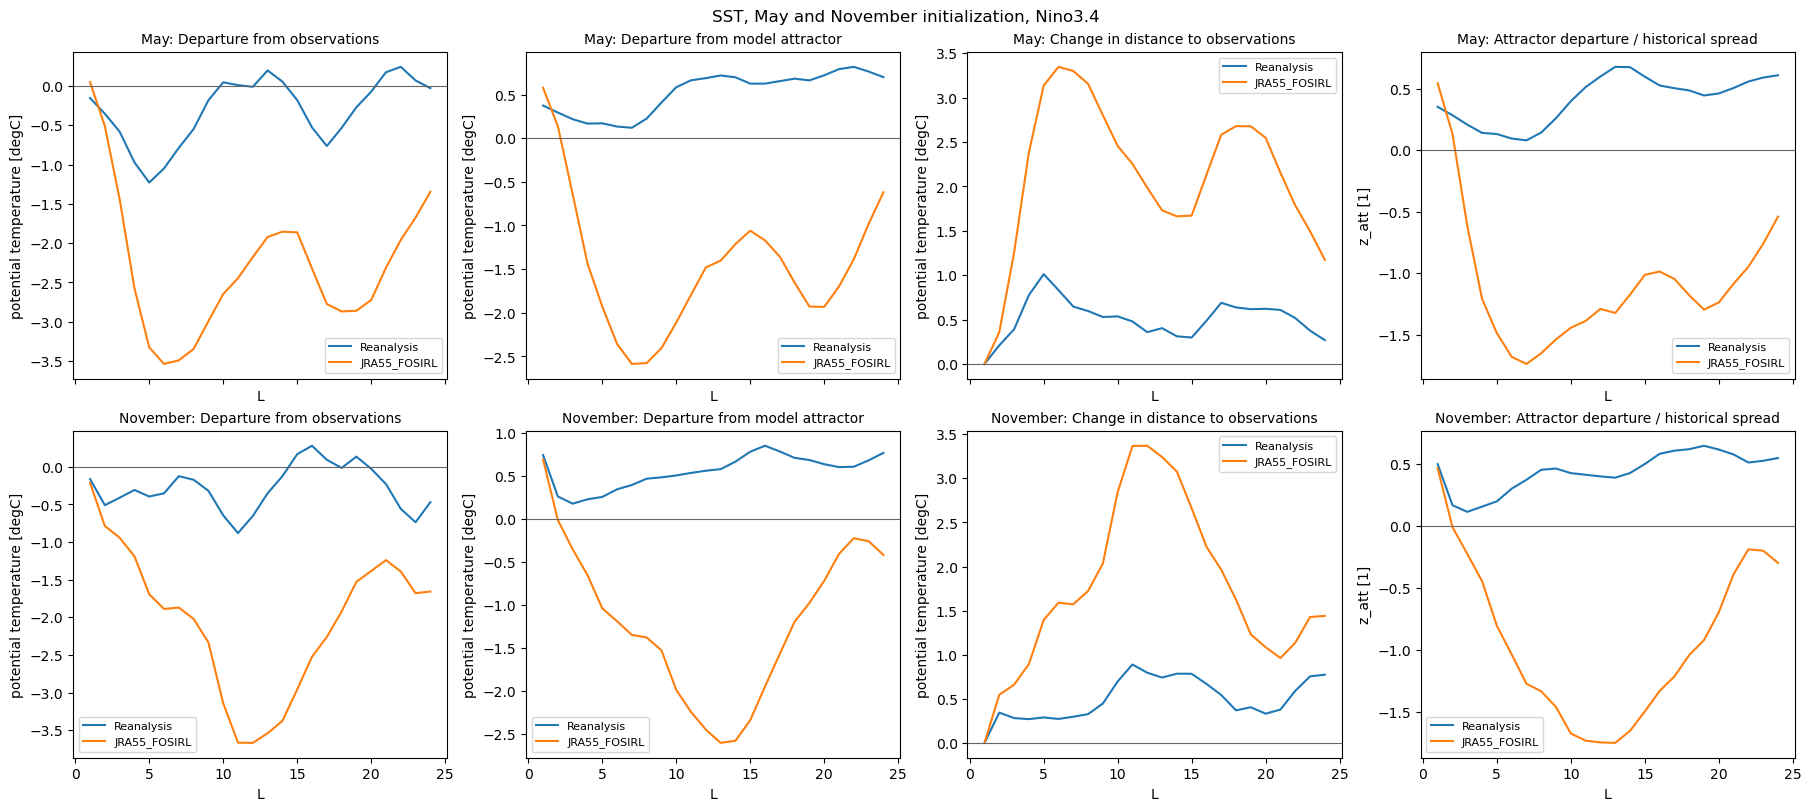

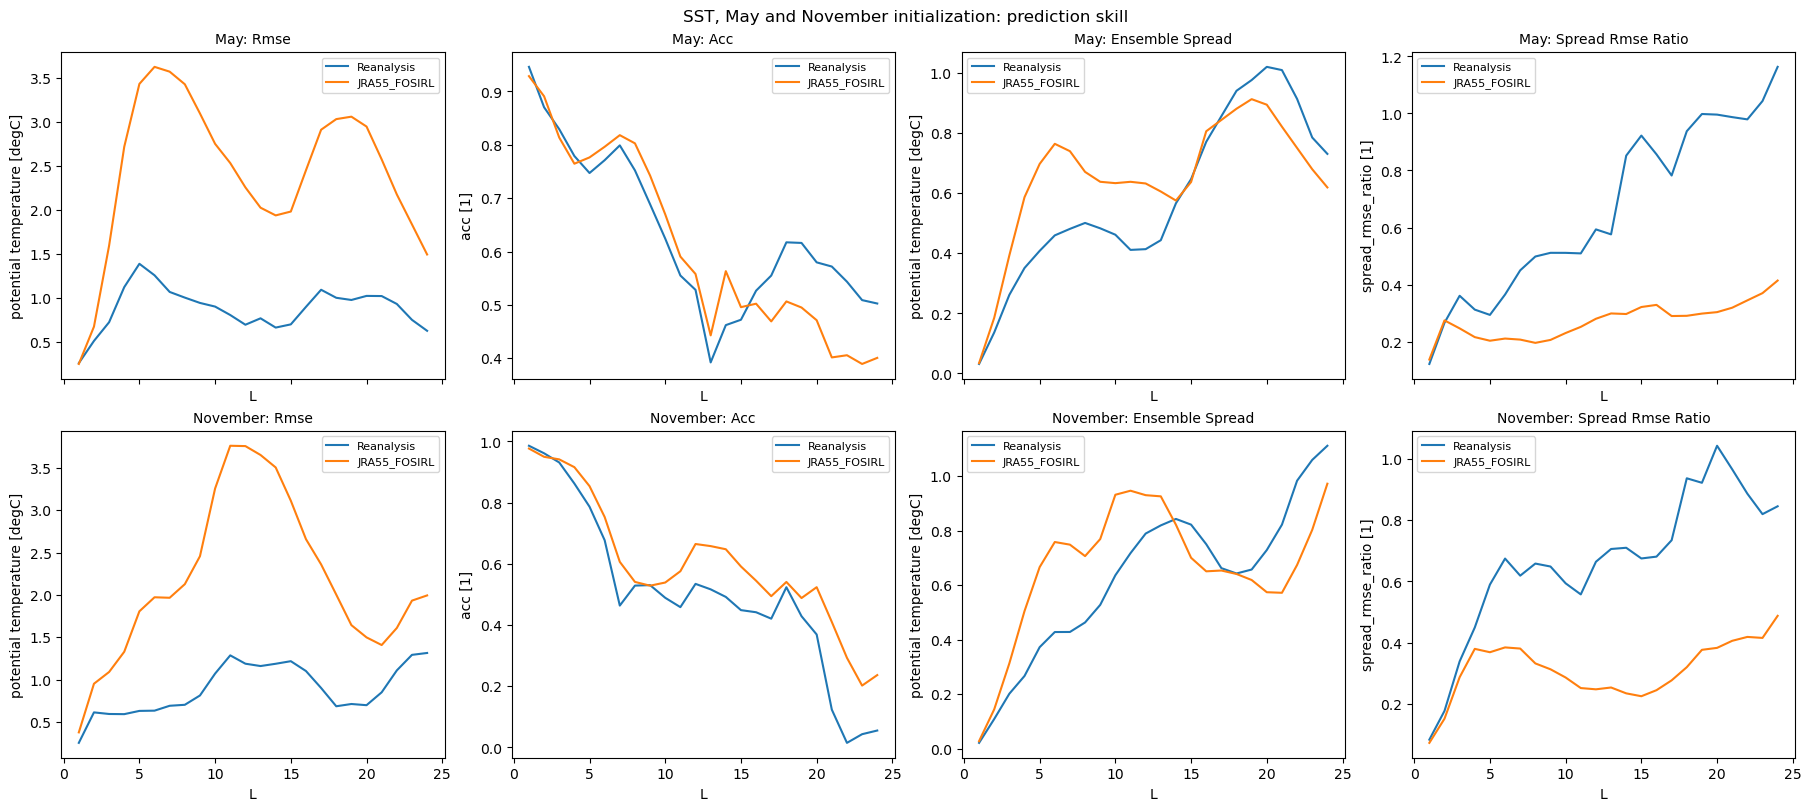

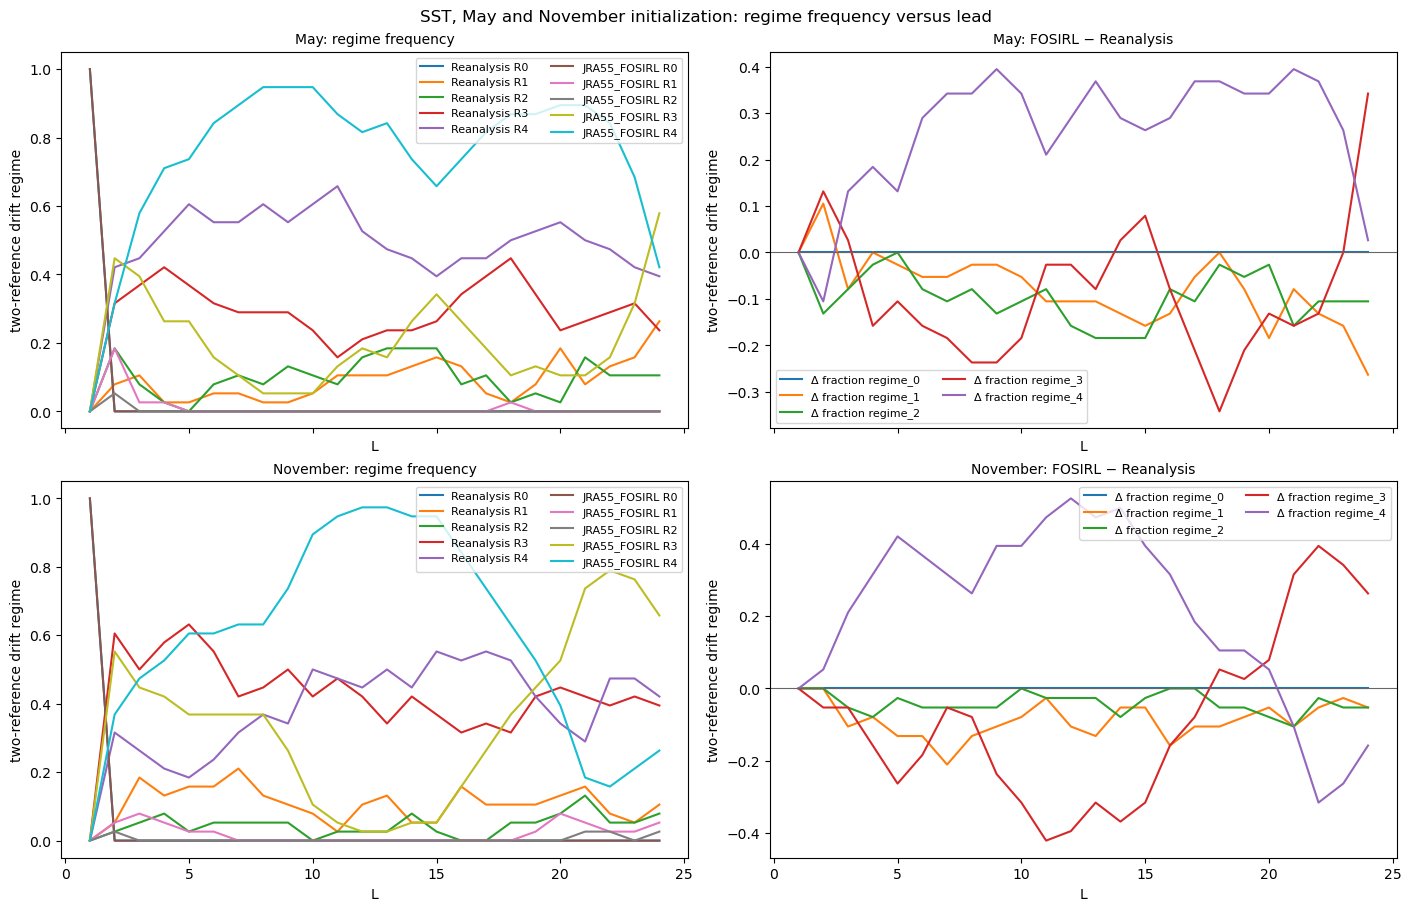

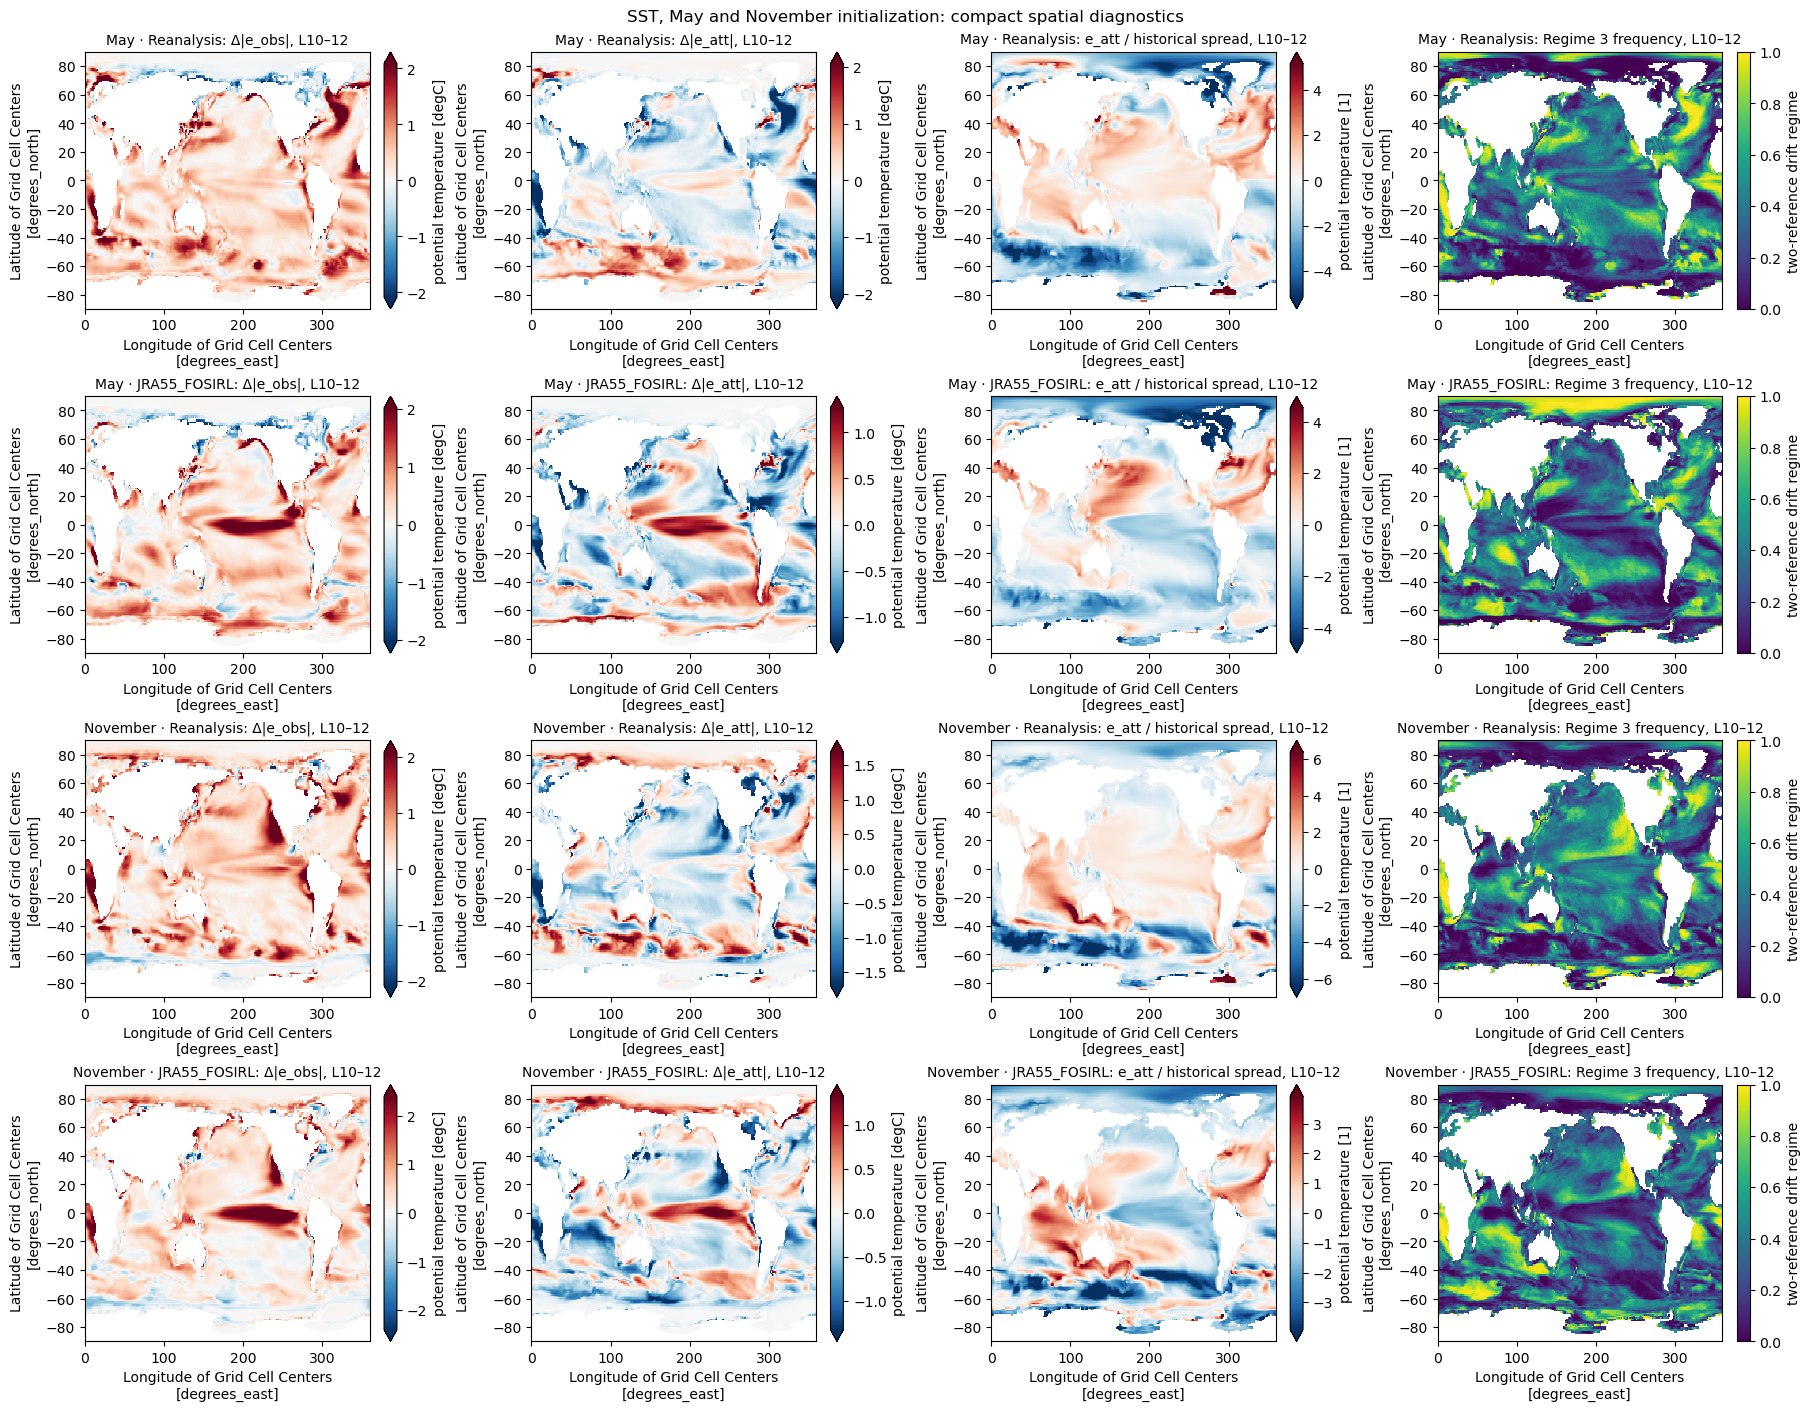

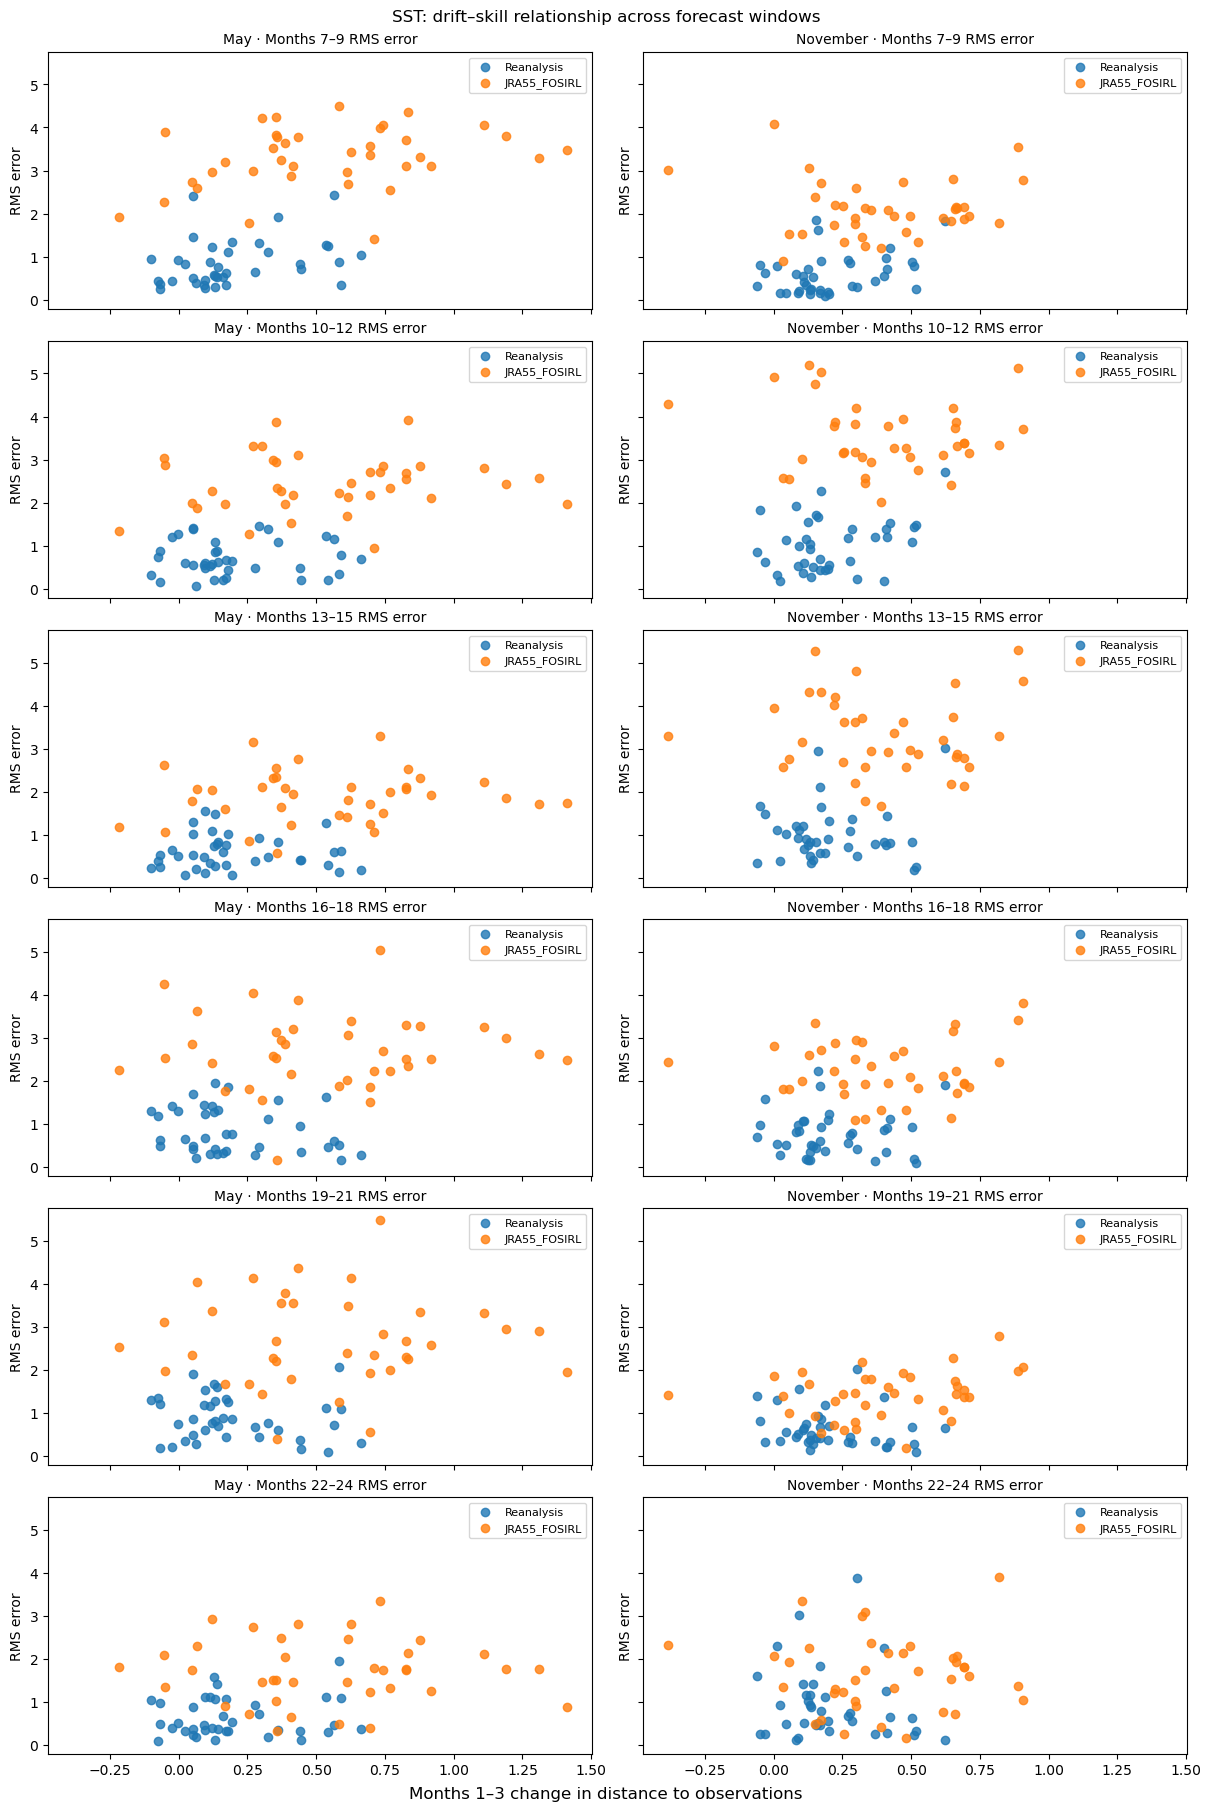

[PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_regional_drift.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_skill.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_spatial_maps.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_drift_skill.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_SST_May_Nov_regional_drift.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_SST_May_Nov_skill.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_SST_May_Nov_regime_fracti

In [36]:
figure_paths = []

for variable in ('TREFHT', 'SST'):
    tag = f'{variable}_May_Nov'

    regional_metrics = (
        ('e_obs', 'Departure from observations'),
        ('e_att', 'Departure from model attractor'),
        ('delta_abs_e_obs', 'Change in distance to observations'),
        ('z_att', 'Attractor departure / historical spread'),
    )
    fig, axes = plt.subplots(
        2, 4, figsize=figure_size('regional_drift'), sharex=True, constrained_layout=True
    )
    for row, init_month in enumerate(INIT_MONTHS):
        result = results[(variable, init_month)]
        for col, (metric, title) in enumerate(regional_metrics):
            ax = axes[row, col]
            for source in SOURCES:
                result['regional'][source][metric].mean('Y', skipna=True).plot(
                    ax=ax, label=source
                )
            ax.axhline(0, color='0.4', linewidth=0.8)
            ax.set_title(f'{MONTH_NAMES[init_month]}: {title}')
            ax.legend()
    fig.suptitle(f'{variable}, May and November initialization, {REGIONS[variable]["name"]}')
    path = FIGURE_ROOT / f'{FIGURE_PREFIX}_{tag}_regional_drift.png'
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if SHOW_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    figure_paths.append(path)

    skill_metrics = ('rmse', 'acc', 'ensemble_spread', 'spread_rmse_ratio')
    fig, axes = plt.subplots(
        2, 4, figsize=figure_size('skill'), sharex=True, constrained_layout=True
    )
    for row, init_month in enumerate(INIT_MONTHS):
        result = results[(variable, init_month)]
        for col, metric in enumerate(skill_metrics):
            ax = axes[row, col]
            for source in SOURCES:
                result['skill'][source][metric].plot(ax=ax, label=source)
            ax.set_title(f'{MONTH_NAMES[init_month]}: {metric.replace("_", " " ).title()}')
            ax.legend()
    fig.suptitle(f'{variable}, May and November initialization: prediction skill')
    path = FIGURE_ROOT / f'{FIGURE_PREFIX}_{tag}_skill.png'
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if SHOW_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    figure_paths.append(path)

    fig, axes = plt.subplots(
        2, 2, figsize=figure_size('regime_fraction'), sharex=True, constrained_layout=True
    )
    for row, init_month in enumerate(INIT_MONTHS):
        result = results[(variable, init_month)]
        for source in SOURCES:
            for code in range(5):
                result['regime_fraction'][source][f'fraction_regime_{code}'].plot(
                    ax=axes[row, 0], label=f'{source} R{code}'
                )
        for name, field in result['paired_regime_fraction'].data_vars.items():
            field.plot(
                ax=axes[row, 1], label=name.replace('delta_fraction_', 'Δ fraction ')
            )
        axes[row, 0].set_title(f'{MONTH_NAMES[init_month]}: regime frequency')
        axes[row, 1].set_title(f'{MONTH_NAMES[init_month]}: FOSIRL − Reanalysis')
        axes[row, 1].axhline(0, color='0.4', linewidth=0.8)
        for ax in axes[row]:
            ax.legend(fontsize=LEGEND_FONT_SIZE, ncol=2)
    fig.suptitle(f'{variable}, May and November initialization: regime frequency versus lead')
    path = FIGURE_ROOT / f'{FIGURE_PREFIX}_{tag}_regime_fraction.png'
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if SHOW_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    figure_paths.append(path)

    map_fields = (
        ('delta_abs_e_obs_late_year1', 'Δ|e_obs|, L10–12', 'RdBu_r'),
        ('delta_abs_e_att_late_year1', 'Δ|e_att|, L10–12', 'RdBu_r'),
        ('z_att_late_year1', 'e_att / historical spread, L10–12', 'RdBu_r'),
        ('fraction_regime_3_late_year1', 'Regime 3 frequency, L10–12', 'viridis'),
    )
    fig, axes = plt.subplots(
        4, 4, figsize=figure_size('spatial_maps'), constrained_layout=True
    )
    for month_index, init_month in enumerate(INIT_MONTHS):
        result = results[(variable, init_month)]
        for source_index, source in enumerate(SOURCES):
            row = month_index * len(SOURCES) + source_index
            for col, (name, title, cmap) in enumerate(map_fields):
                field = result['spatial'][source][name]
                kwargs = {'cmap': cmap}
                if cmap == 'RdBu_r':
                    limit = float(abs(field).quantile(0.98, skipna=True))
                    kwargs.update(vmin=-limit, vmax=limit)
                else:
                    kwargs.update(vmin=0, vmax=1)
                field.plot.pcolormesh(ax=axes[row, col], x='lon', y='lat', **kwargs)
                axes[row, col].set_title(
                    f'{MONTH_NAMES[init_month]} · {source}: {title}'
                )
    fig.suptitle(f'{variable}, May and November initialization: compact spatial diagnostics')
    path = FIGURE_ROOT / f'{FIGURE_PREFIX}_{tag}_spatial_maps.png'
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if SHOW_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    figure_paths.append(path)

    fig, axes = plt.subplots(
        len(DRIFT_SKILL_ERROR_WINDOWS), len(INIT_MONTHS),
        figsize=figure_size('drift_skill'), sharex=True, sharey=True,
        squeeze=False, constrained_layout=True,
    )
    for row, error_leads in enumerate(DRIFT_SKILL_ERROR_WINDOWS):
        error_months = lead_month_range(error_leads)
        for col, init_month in enumerate(INIT_MONTHS):
            ax = axes[row, col]
            result = results[(variable, init_month)]
            for source in SOURCES:
                relationship = compute_early_drift_late_error(
                    result['regional'][source].delta_abs_e_obs,
                    result['regional'][source].e_obs,
                    early_leads=EARLY_LEADS, late_leads=error_leads,
                )
                ax.scatter(
                    relationship.early_drift, relationship.late_error,
                    label=source, alpha=0.8,
                )
            ax.set_title(f'{MONTH_NAMES[init_month]} · {error_months} RMS error')
            ax.set_ylabel('RMS error')
            ax.legend()
    adjustment_months = lead_month_range(EARLY_LEADS)
    fig.supxlabel(f'{adjustment_months} change in distance to observations')
    fig.suptitle(f'{variable}: drift–skill relationship across forecast windows')
    path = FIGURE_ROOT / f'{FIGURE_PREFIX}_{tag}_drift_skill.png'
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if SHOW_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    figure_paths.append(path)

assert len(figure_paths) == 2 * 5
figure_paths

## 5. Validation / smoke tests

In [37]:
assert set(results) == {(variable, month) for variable in ('TREFHT', 'SST') for month in (5, 11)}
for (variable, init_month), result in results.items():
    for source in SOURCES:
        product = result['regional'][source]
        assert product.hindcast_mean.dims == ('Y', 'L')
        assert product.z_att.attrs['units'] == '1'
        for name in ('delta_e_obs', 'delta_e_att', 'delta_abs_e_obs', 'delta_abs_e_att'):
            np.testing.assert_allclose(product[name].sel(L=BASELINE_LEAD).fillna(0), 0, atol=1e-12)
        regimes = set(np.unique(product.regime.values[np.isfinite(product.regime.values)]).astype(int))
        assert regimes <= {0, 1, 2, 3, 4}
        fractions = result['regime_fraction'][source].to_array().sum('variable')
        np.testing.assert_allclose(fractions.where(fractions.notnull(), 1), 1, atol=1e-10)
        assert {'lat', 'lon'} <= set(result['spatial'][source].dims)
        assert any(name.startswith('z_att_') for name in result['spatial'][source].data_vars)
    assert set(result['paired_regime_fraction'].data_vars) == {f'delta_fraction_regime_{code}' for code in range(5)}
    np.testing.assert_array_equal(
        result['regional']['Reanalysis'].Y, result['regional']['JRA55_FOSIRL'].Y
    )
    assert result['paired'].attrs.get('comparison') == 'JRA55_FOSIRL minus Reanalysis'
print(f'Validated {len(results)} analyses, {len(output_paths)} outputs, and {len(figure_paths)} figures.')

Validated 4 analyses, 25 outputs, and 10 figures.
